# KATL/KDAL V20 Cost-Sensitive Half-Up Override V4

V4 keeps nearest half-up rounding as the default. It fits two calibrated binary heads on
**actionable rows only**:

- recovery: the alternative bucket wins and half-up loses;
- damage: half-up wins and the alternative bucket loses.

The decision is `p(recovery) - damage_penalty * p(damage) > minimum_margin`, with a separate
minimum recovery probability. A policy is enabled only when it has positive `recoveries -
2*damages`, is positive in at least two of three earlier chronological policy folds, and is harmful
in none. Otherwise V4 automatically makes no overrides.


## Environment and contracts


In [1]:
from pathlib import Path
import sys
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.errors import PerformanceWarning

warnings.simplefilter("ignore", PerformanceWarning)
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.calibration.round_override_v4 import (
    audit_utility_override_system,
    build_utility_override_frame,
    fit_utility_override_system,
    predict_utility_override,
    serializable_utility_bundle,
    utility_override_metrics,
)
from src.calibration.v19_bucket import crossfit_ridge_predictions

STATIONS = {
    "KATL": {"pipeline": PROJECT_ROOT / "data/calibration/station_stacking_v20_peak_timing", "peak": True},
    "KDAL": {"pipeline": PROJECT_ROOT / "data/calibration/station_stacking_v20_kdal_no_peak", "peak": False},
}
print(PROJECT_ROOT)


D:\dev\weather-research


## Build exact recovery/damage targets and prior-only continuous features


In [2]:
frames, sources, summaries = {}, {}, []
for station, config in STATIONS.items():
    features = pd.read_csv(config["pipeline"] / f"{station}_features.csv", low_memory=False)
    validation = pd.read_csv(config["pipeline"] / f"{station}_year_split_validation_predictions.csv")
    point = crossfit_ridge_predictions(validation)
    frame = build_utility_override_frame(
        features, point, validation, include_peak_features=config["peak"]
    )
    frames[station] = frame
    sources[station] = {"features": features, "validation": validation, "point": point}
    actionable = frame.loc[frame["override_actionable"].eq(1)]
    summaries.append({
        "station": station,
        "rows": len(frame),
        "start": frame["contract_date"].min().date(),
        "end": frame["contract_date"].max().date(),
        "actionable_rows": len(actionable),
        "recovery_rate_given_actionable": actionable["recovery_target"].mean(),
        "damage_rate_given_actionable": actionable["damage_target"].mean(),
        "default_bucket_hit_rate": frame["default_bucket_win"].mean(),
    })
dataset_summary = pd.DataFrame(summaries)
dataset_summary


,station,rows,start,end,actionable_rows,recovery_rate_given_actionable,damage_rate_given_actionable,default_bucket_hit_rate
0,KATL,1092,2023-01-01,2025-12-31,528,0.32197,0.450758,0.458791
1,KDAL,1091,2023-01-01,2025-12-31,511,0.35225,0.420744,0.451879


In [3]:
display_columns = [
    "contract_date", "point_prediction_f", "default_bucket_label", "alternative_bucket_label",
    "override_actionable", "actual_bucket_label", "recovery_target", "damage_target",
    "prior_residual_mean_180d_f", "prior_residual_std_180d_f",
    "continuous_default_bucket_probability_180d",
    "continuous_alternative_bucket_probability_180d",
]
pd.concat(
    [frame.assign(station=station).tail(5) for station, frame in frames.items()]
)[["station", *display_columns]]


,station,contract_date,point_prediction_f,default_bucket_label,alternative_bucket_label,override_actionable,actual_bucket_label,recovery_target,damage_target,prior_residual_mean_180d_f,prior_residual_std_180d_f,continuous_default_bucket_probability_180d,continuous_alternative_bucket_probability_180d
1087,KATL,2025-12-27,74.929603,74-75,74-75,0,76-77,0,0,-0.105348,1.617385,0.524178,0.524178
1088,KATL,2025-12-28,68.777910,68-69,68-69,0,68-69,0,0,-0.089016,1.624415,0.532155,0.532155
1089,KATL,2025-12-29,64.102522,64-65,64-65,0,64-65,0,0,-0.081774,1.622880,0.505938,0.505938
1090,KATL,2025-12-30,42.979544,42-43,42-43,0,42-43,0,0,-0.085233,1.622257,0.516087,0.516087
1091,KATL,2025-12-31,51.562565,52-53,50-51,1,52-53,0,1,-0.084663,1.621924,0.409115,0.418565
1086,KDAL,2025-12-27,81.270326,80-81,82-83,1,80-81,0,1,0.349601,1.551839,0.393161,0.448511
1087,KDAL,2025-12-28,78.762961,78-79,78-79,0,84-85,0,0,0.344906,1.555451,0.501203,0.501203
1088,KDAL,2025-12-29,44.002291,44-45,44-45,0,42-43,0,0,0.362222,1.592037,0.543016,0.543016
1089,KDAL,2025-12-30,51.440931,50-51,52-53,1,52-53,1,0,0.370147,1.581641,0.345884,0.481905
1090,KDAL,2025-12-31,66.279085,66-67,66-67,0,66-67,0,0,0.376195,1.584092,0.544259,0.544259


## Nested chronological V4 fitting


In [4]:
results = {}
for station, config in STATIONS.items():
    print(f"Training V4 {station}...")
    results[station] = fit_utility_override_system(
        frames[station], station_id=station, include_peak_features=config["peak"]
    )
print("Training complete")


Training V4 KATL...


Training V4 KDAL...


Training complete


## Selected heads and stability-gated policies


In [5]:
fold_states = pd.concat(
    [result["fold_states"].assign(station=station) for station, result in results.items()],
    ignore_index=True,
)
fold_states[[
    "station", "validation_year", "recovery_family", "damage_family", "policy_enabled",
    "damage_penalty", "minimum_recovery_probability", "minimum_utility_margin",
    "training_actionable_rows", "training_non_actionable_rows", "model_training_cutoff",
    "calibration_start", "calibration_cutoff", "policy_start", "policy_cutoff",
]]


,station,validation_year,recovery_family,damage_family,policy_enabled,damage_penalty,minimum_recovery_probability,minimum_utility_margin,training_actionable_rows,training_non_actionable_rows,model_training_cutoff,calibration_start,calibration_cutoff,policy_start,policy_cutoff
0,KATL,2024,logistic,catboost,False,4.0,1.1,inf,97,0,2023-07-04,2023-07-05,2023-10-02,2023-10-03,2023-12-31
1,KATL,2025,catboost,catboost,False,4.0,1.1,inf,262,0,2024-07-04,2024-07-05,2024-10-02,2024-10-03,2024-12-31
2,KDAL,2024,logistic,logistic,False,4.0,1.1,inf,86,0,2023-07-04,2023-07-05,2023-10-02,2023-10-03,2023-12-31
3,KDAL,2025,catboost,logistic,False,4.0,1.1,inf,252,0,2024-07-04,2024-07-05,2024-10-02,2024-10-03,2024-12-31


## Honest 2024-2025 forward result


In [6]:
forward_metrics = pd.concat(
    [result["forward_metrics"].assign(station=station) for station, result in results.items()],
    ignore_index=True,
)
result_columns = [
    "station", "period", "count", "actionable_count", "default_bucket_hit_rate",
    "final_bucket_hit_rate", "bucket_hit_rate_lift", "override_count", "recovered_losses",
    "damaged_wins", "net_recovered_wins", "recovery_damage_ratio",
    "recovery_log_loss", "recovery_ece", "recovery_roc_auc",
    "damage_log_loss", "damage_ece", "damage_roc_auc",
]
forward_metrics[result_columns]


,station,period,count,actionable_count,default_bucket_hit_rate,final_bucket_hit_rate,bucket_hit_rate_lift,override_count,recovered_losses,damaged_wins,net_recovered_wins,recovery_damage_ratio,recovery_log_loss,recovery_ece,recovery_roc_auc,damage_log_loss,damage_ece,damage_roc_auc
0,KATL,2024,365,185,0.493151,0.493151,0.0,0,0,0,0,NaN,0.647770,0.178187,0.591852,0.776919,0.195155,0.524784
1,KATL,2025,364,169,0.505495,0.505495,0.0,0,0,0,0,NaN,0.669169,0.125228,0.475114,0.702039,0.074034,0.489916
2,KATL,2024-2025,729,354,0.499314,0.499314,0.0,0,0,0,0,NaN,0.657986,0.152904,0.491858,0.741171,0.137332,0.509991
3,KDAL,2024,364,171,0.469780,0.469780,0.0,0,0,0,0,NaN,0.662517,0.111061,0.529210,0.667989,0.055362,0.576740
4,KDAL,2025,364,174,0.502747,0.502747,0.0,0,0,0,0,NaN,0.657181,0.082360,0.511864,0.705560,0.095053,0.492444
5,KDAL,2024-2025,728,345,0.486264,0.486264,0.0,0,0,0,0,NaN,0.659826,0.096586,0.520000,0.686938,0.075380,0.542361


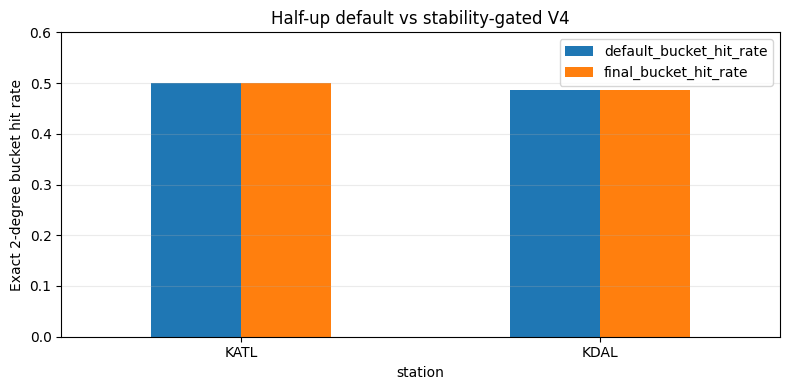

In [7]:
combined = forward_metrics.loc[forward_metrics["period"].eq("2024-2025")]
plot_data = combined.set_index("station")[["default_bucket_hit_rate", "final_bucket_hit_rate"]]
ax = plot_data.plot(kind="bar", figsize=(8, 4), ylim=(0, 0.6))
ax.set_title("Half-up default vs stability-gated V4")
ax.set_ylabel("Exact 2-degree bucket hit rate")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Exploratory sequential 2026 evaluation


In [8]:
holdout_predictions, holdout_rows = {}, []
for station, config in STATIONS.items():
    source = sources[station]
    test = pd.read_csv(config["pipeline"] / f"{station}_year_split_test_predictions.csv")
    test_point = test.loc[
        test["method"].eq("ridge_stack"),
        ["contract_date", "actual_high_f", "predicted_high_f"],
    ]
    all_point = pd.concat(
        [source["point"][["contract_date", "actual_high_f", "predicted_high_f"]], test_point],
        ignore_index=True,
    )
    all_base = pd.concat([source["validation"], test], ignore_index=True)
    all_frame = build_utility_override_frame(
        source["features"], all_point, all_base, include_peak_features=config["peak"]
    )
    holdout = all_frame.loc[all_frame["year"].eq(2026)]
    predicted = predict_utility_override(results[station]["final_state"], holdout)
    holdout_predictions[station] = predicted
    holdout_rows.append({"station": station, **utility_override_metrics(predicted)})
holdout_metrics = pd.DataFrame(holdout_rows)
holdout_metrics[[
    "station", "count", "default_bucket_hit_rate", "final_bucket_hit_rate",
    "bucket_hit_rate_lift", "override_count", "recovered_losses", "damaged_wins",
    "net_recovered_wins", "recovery_log_loss", "damage_log_loss",
]]


,station,count,default_bucket_hit_rate,final_bucket_hit_rate,bucket_hit_rate_lift,override_count,recovered_losses,damaged_wins,net_recovered_wins,recovery_log_loss,damage_log_loss
0,KATL,172,0.465116,0.465116,0.0,0,0,0,0,0.667460,0.688987
1,KDAL,170,0.482353,0.482353,0.0,0,0,0,0,0.617825,0.713925


## Executable V4 audit


In [9]:
audit_parts = []
for station, config in STATIONS.items():
    audit_parts.append(
        audit_utility_override_system(
            frames[station], results[station], include_peak_features=config["peak"]
        ).assign(station=station)
    )
    frame = frames[station]
    audit_parts.append(pd.DataFrame([
        {"station": station, "audit": "unique_station_dates", "passed": not frame["contract_date"].duplicated().any(), "detail": f"duplicates={int(frame['contract_date'].duplicated().sum())}"},
        {"station": station, "audit": "integer_settlement_labels", "passed": bool(np.allclose(frame["actual_high_f"], np.round(frame["actual_high_f"]))), "detail": f"rows={len(frame)}"},
    ]))
audit_report = pd.concat(audit_parts, ignore_index=True)[["station", "audit", "passed", "detail"]]
display(audit_report)
failed = audit_report.loc[~audit_report["passed"]]
assert failed.empty, failed.to_dict(orient="records")
print(f"All {len(audit_report)} V4 audits passed")


,station,audit,passed,detail
0,KATL,recovery_target_formula,True,alternative wins and half-up loses
1,KATL,damage_target_formula,True,half-up wins and alternative loses
2,KATL,targets_are_mutually_exclusive,True,a row cannot recover and damage simultaneously
3,KATL,non_actionable_targets_are_zero,True,non-actionable rows cannot create utility
4,KATL,training_uses_actionable_rows_only,True,outer_folds=2 plus final
5,KATL,continuous_features_are_strictly_prior,True,rolling residuals use shift(1)
6,KATL,continuous_probabilities_are_valid,True,checked=4248
7,KATL,continuous_probability_advantage_formula,True,alternative probability minus default probability
8,KATL,compact_feature_inventory,True,features=36
9,KATL,all_outer_rows_scored,True,outer_rows=729


All 50 V4 audits passed


## Export research artifacts


In [10]:
OUTPUT_ROOT = PROJECT_ROOT / "data/calibration/station_round_override_v4"
exports = []
for station, result in results.items():
    output = OUTPUT_ROOT / station
    weights = output / "model_weights"
    weights.mkdir(parents=True, exist_ok=True)
    result["forward_predictions"].to_csv(output / f"{station}_v4_forward_predictions.csv", index=False)
    result["forward_metrics"].to_csv(output / f"{station}_v4_forward_metrics.csv", index=False)
    result["fold_states"].to_csv(output / f"{station}_v4_fold_states.csv", index=False)
    result["tuning"].to_csv(output / f"{station}_v4_head_tuning.csv", index=False)
    result["policy_tuning"].to_csv(output / f"{station}_v4_policy_tuning.csv", index=False)
    result["final_tuning"].to_csv(output / f"{station}_v4_final_head_tuning.csv", index=False)
    result["final_policy_tuning"].to_csv(output / f"{station}_v4_final_policy_tuning.csv", index=False)
    holdout_predictions[station].to_csv(output / f"{station}_v4_2026_predictions.csv", index=False)
    bundle = weights / f"{station}_half_up_utility_override_v4.joblib"
    joblib.dump(serializable_utility_bundle(result), bundle)
    exports.append({
        "station": station,
        "bundle": str(bundle),
        "final_policy_enabled": result["final_state"]["policy_enabled"],
    })
audit_report.to_csv(OUTPUT_ROOT / "v4_audit.csv", index=False)
dataset_summary.to_csv(OUTPUT_ROOT / "dataset_summary.csv", index=False)
holdout_metrics.to_csv(OUTPUT_ROOT / "exploratory_2026_metrics.csv", index=False)
pd.DataFrame(exports)


,station,bundle,final_policy_enabled
0,KATL,D:\dev\weather-research\data\calibration\stati...,False
1,KDAL,D:\dev\weather-research\data\calibration\stati...,False


## Acceptance rule

V4 is accepted for overrides only if each honest outer year has positive net recovered wins, no
year has negative bucket-hit lift, recovery/damage exceeds 1, and the final policy passes the
three-fold prior stability gate. An abstaining policy is a valid safety result but does not prove
that the classifier adds value over half-up.
